In [2]:
import pandas as pd
import geemap
from google.colab import drive
import geopandas as gpd
import ee

drive.mount('/content/drive')

ee.Authenticate()
ee.Initialize(project='lucasvituri')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Cargamos las capas vectoriales (Shapefiles)
provincias = gpd.read_file('/content/drive/MyDrive/INTROSIG_T1_GEE/Provincias.shp')
# Reproyectar y asignar de nuevo a la variable
provincias = provincias.to_crs('EPSG:4326') # Dejar los crs iguales para la intersección de datos
print("CRS de provincias después de reproyectar: ", provincias.crs)

catastro = gpd.read_file('/content/drive/MyDrive/INTROSIG_T1_GEE/5__cubierta_frutal_de_pol_gonos_regi_n_de_valpara_so_2025.shp')
# Reproyectar y asignar de nuevo a la variable
catastro = catastro.to_crs('EPSG:4326')
print("CRS de catastro después de reproyectar: ", catastro.crs)

# INTERSECCIÓN ESPACIAL: Traspasamos la información de la provincia a cada parcela
# Esto une ambas tablas basándose en su ubicación geográfica (superposición)
catastro_con_provincia = gpd.overlay(catastro, provincias, how='intersection')

# 4. Ahora podemos filtrar por Província y Especie (Palto en Petorca)
# Asegúrate de que 'Provincia' y 'ESPECIE' existan en catastro_con_provincia
prov_petorca = provincias[provincias['Provincia'] == 'Petorca']
paltos_petorca = catastro_con_provincia[(catastro_con_provincia['ESPECIE'] == 'PALTO') & #Confirme siempre la forma como se presentan las columnas y nombres
                                        (catastro_con_provincia['Provincia'] == 'Petorca')]
limon_petorca = catastro_con_provincia[(catastro_con_provincia['ESPECIE'] == 'LIMONERO') &
                                        (catastro_con_provincia['Provincia'] == 'Petorca')]

print(f"Parcelas de Paltos encontradas en Petorca: {len(paltos_petorca)}")
print(f"Parcelas de Limonero encontradas en Petorca: {len(vid_petorca)}")

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: Geometry of polygon of fid 56 cannot be translated to Simple Geometry. All polygons will be contained in a multipolygon.
  return ogr_read(


CRS de provincias después de reproyectar:  EPSG:4326
CRS de catastro después de reproyectar:  EPSG:4326
Parcelas de Paltos encontradas en Petorca: 1628


NameError: name 'vid_petorca' is not defined

In [ ]:
# Definimos las colecciones
smap_col = ee.ImageCollection("NASA/SMAP/SPL4SMGP/008")
ndvi_col = ee.ImageCollection("MODIS/061/MOD13Q1")

def extract_data_by_species(geometry, label):
    # Usamos el bounding box de la geometría total para asegurar que cubra el área del sensor
    region = geometry.bounds()

    def monthly_map(month_num):
        month_num = ee.Number(month_num)
        fecha_ini = ee.Date.fromYMD(2023, month_num, 1)
        fecha_fin = fecha_ini.advance(1, 'month')

        # Procesamiento SMAP (Humedad)
        h_coll = smap_col.filterBounds(region).filterDate(fecha_ini, fecha_fin).select('sm_profile')
        h_img = h_coll.mean()

        # Procesamiento MODIS (NDVI)
        v_coll = ndvi_col.filterBounds(region).filterDate(fecha_ini, fecha_fin).select('NDVI')
        v_img = v_coll.mean().multiply(0.0001)

        # Reducción con validación
        h_stats = ee.Dictionary(ee.Algorithms.If(h_coll.size().gt(0),
            h_img.reduceRegion(reducer=ee.Reducer.mean(), geometry=region, scale=9000),
            ee.Dictionary({'sm_profile': 0})))

        v_stats = ee.Dictionary(ee.Algorithms.If(v_coll.size().gt(0),
            v_img.reduceRegion(reducer=ee.Reducer.mean(), geometry=region, scale=250),
            ee.Dictionary({'NDVI': 0})))

        return ee.Feature(None, {
            'Mes': month_num,
            'Humedad': h_stats.get('sm_profile', 0),
            'NDVI': v_stats.get('NDVI', 0),
            'Especie': label
        })

    months = ee.List.sequence(1, 12)
    return ee.FeatureCollection(months.map(monthly_map)).getInfo()

try:
    # Convertimos los GeoDataFrames de Petorca a objetos de Earth Engine
    # Usamos los nombres definidos en la celda czABn6ImFZXL
    geom_paltos_ee = geemap.geopandas_to_ee(paltos_petorca).geometry()
    geom_limon_ee = geemap.geopandas_to_ee(limon_petorca).geometry()

    print("Iniciando extracción de datos para Palto y Limonero en Petorca...")

    res_paltos = extract_data_by_species(geom_paltos_ee, 'PALTO')
    res_limon = extract_data_by_species(geom_limon_ee, 'LIMONERO')

    # 3. Procesamos los resultados
    datos_paltos = [f['properties'] for f in res_paltos['features']]
    datos_limon = [f['properties'] for f in res_limon['features']]

    df_comparativo = pd.DataFrame(datos_paltos + datos_limon)

    print("¡Extracción completada!")
    display(df_comparativo.head(15))

except Exception as e:
    print(f"Error durante la ejecución: {e}")

Iniciando extracción de datos para Palto y Limonero en Petorca...
¡Extracción completada!


,Especie,Humedad,Mes,NDVI
0,PALTO,0.154279,1,0.312421
1,PALTO,0.147392,2,0.297671
2,PALTO,0.143898,3,0.301154
3,PALTO,0.142491,4,0.301802
4,PALTO,0.145894,5,0.286821
5,PALTO,0.155447,6,0.298546
6,PALTO,0.188649,7,0.373223
7,PALTO,0.211591,8,0.469506
8,PALTO,0.233214,9,0.534178
9,PALTO,0.212803,10,0.470542


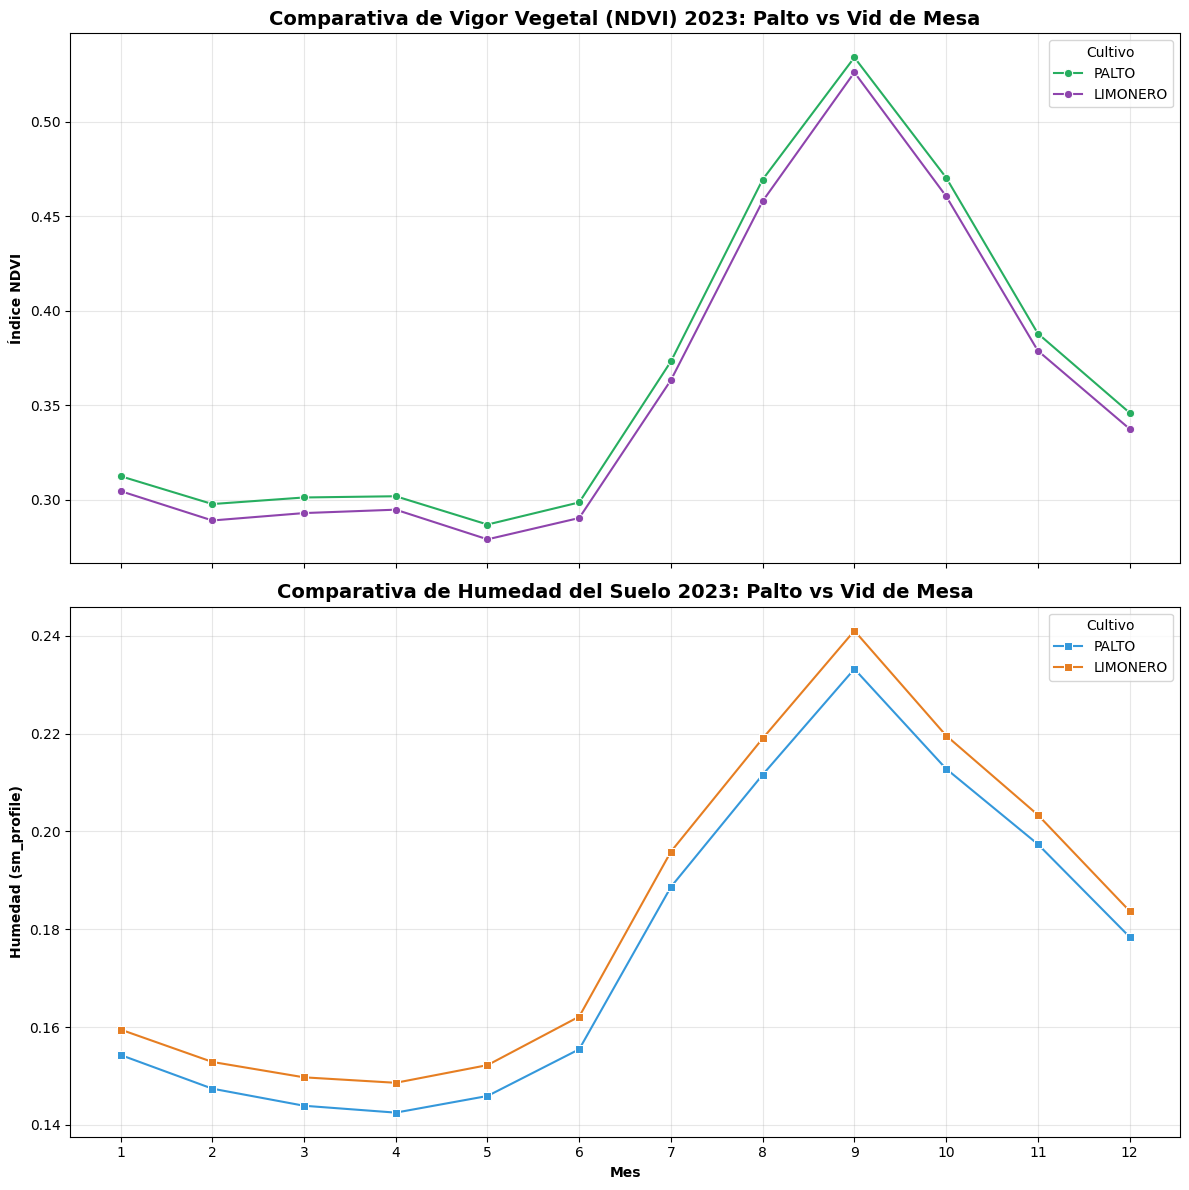

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos la figura con dos subplots (uno arriba del otro)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Subplot 1: Comparativa de NDVI
sns.lineplot(data=df_comparativo, x='Mes', y='NDVI', hue='Especie', marker='o', palette=['#27ae60', '#8e44ad'], ax=ax1)
ax1.set_title('Comparativa de Vigor Vegetal (NDVI) 2023: Palto vs Vid de Mesa', fontsize=14, fontweight='bold')
ax1.set_ylabel('Índice NDVI', fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend(title='Cultivo')

# Subplot 2: Comparativa de Humedad
sns.lineplot(data=df_comparativo, x='Mes', y='Humedad', hue='Especie', marker='s', palette=['#3498db', '#e67e22'], ax=ax2)
ax2.set_title('Comparativa de Humedad del Suelo 2023: Palto vs Vid de Mesa', fontsize=14, fontweight='bold')
ax2.set_ylabel('Humedad (sm_profile)', fontweight='bold')
ax2.set_xlabel('Mes', fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.grid(alpha=0.3)
ax2.legend(title='Cultivo')

plt.tight_layout()
plt.show()

In [ ]:
# Crearemos el mapa enfocado en el mes más critico del verano (Febrero)
mapa_frutales = geemap.Map()

# Definimos las parcelas en formato EE para el mapa
# Usamos los nombres de las variables creadas en la celda czABn6ImFZXL
parcelas_paltos_ee = geemap.geopandas_to_ee(paltos_petorca)
parcelas_limon_ee = geemap.geopandas_to_ee(limon_petorca)

mapa_frutales.centerObject(parcelas_paltos_ee, zoom=10)

# Filtramos las imágenes de satélite especificamente para Febrero de 2023
smap_feb = ee.ImageCollection("NASA/SMAP/SPL4SMGP/008")\
             .filterDate('2023-02-01', '2023-02-28').select('sm_profile').mean()
ndvi_feb = ee.ImageCollection("MODIS/061/MOD13Q1")\
             .filterDate('2023-02-01', '2023-02-28').select('NDVI').mean().multiply(0.0001)

# Añadimos las capas Raster (usamos la zona de estudio de Petorca)
zona_ee = geemap.geopandas_to_ee(prov_petorca)

paleta_h = ['#d73027', '#fdae61', '#a6d96a', '#1a9641']
mapa_frutales.addLayer(smap_feb.clip(zona_ee), {'min': 0, 'max': 0.5, 'palette': paleta_h}, 'Humedad (Feb)')
mapa_frutales.addLayer(ndvi_feb.clip(zona_ee), {'min': 0.2, 'max': 0.8, 'palette': ['white', 'green']}, 'NDVI (Feb)')

# Añadimos los polígonos de las plantaciones por encima
bordes_palto = ee.Image().byte().paint(featureCollection=parcelas_paltos_ee, color=1, width=2)
mapa_frutales.addLayer(bordes_palto, {'palette': ['black']}, 'Plantaciones de Palto')

bordes_limon = ee.Image().byte().paint(featureCollection=parcelas_limon_ee, color=1, width=2)
mapa_frutales.addLayer(bordes_limon, {'palette': ['green']}, 'Plantaciones de Limonero')

display(mapa_frutales)

Map(center=[-32.412743407931956, -71.03887249815378], controls=(WidgetControl(options=['position', 'transparen…